In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree
from sklearn.impute import KNNImputer
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
import pickle

# Analisis EDA

Prediciendo la diabetes

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.


    Pregnancies. Número de embarazos del paciente (numérico)
    Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
    BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
    SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
    Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
    BMI. Índice de masa corporal (numérico)
    DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
    Age. Edad del paciente (numérico)
    Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)


In [29]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
df = pd.read_csv(url)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Haremos un EDA sencillo en el que sobretodo nos enfocaremos en reemplazar valores nulos o 0 con la mediana en este caso

In [30]:
df.shape

(768, 9)

In [31]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [36]:
columnas_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columnas_con_ceros:
    df[col] = df[col].replace(0, df[col].median())

En este caso vamos a usar la mediana porque es mas robusta al tratar los outliers, ademas de no tener que eliminar filas y mantener el dataset original.

In [37]:
(df[columnas_con_ceros] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### Conclusion EDA
Como podemos observar nuestro dataframe no incluye ningun valor nulo ni ningun valor duplicado, los tipos de datos son todos numericos. Lo que hemos hecho para ayudar al modelo es cambiar los valores  ceros por la mediana para prevenir posibles problematicas en las variables.

## Analisis Univariante

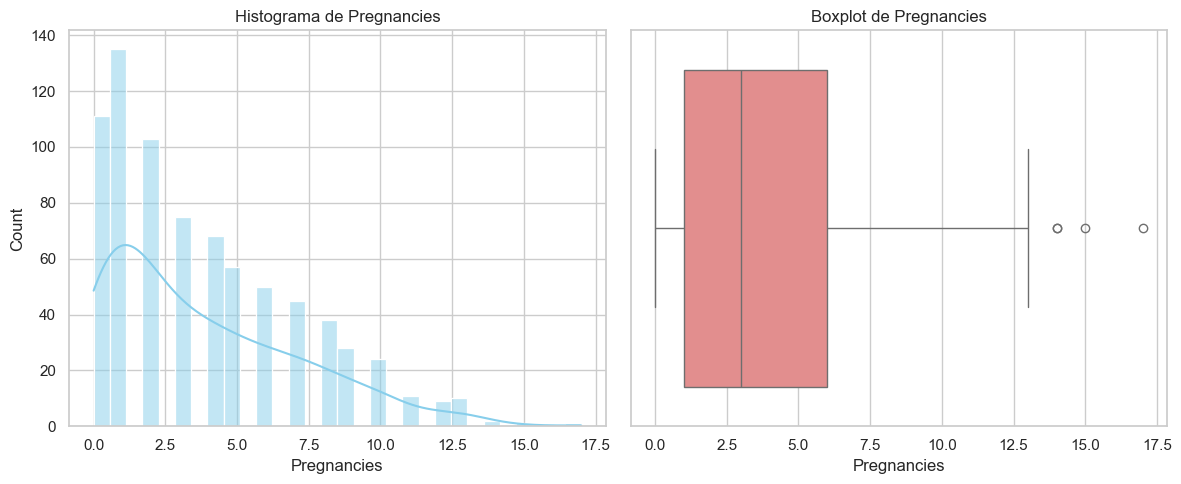

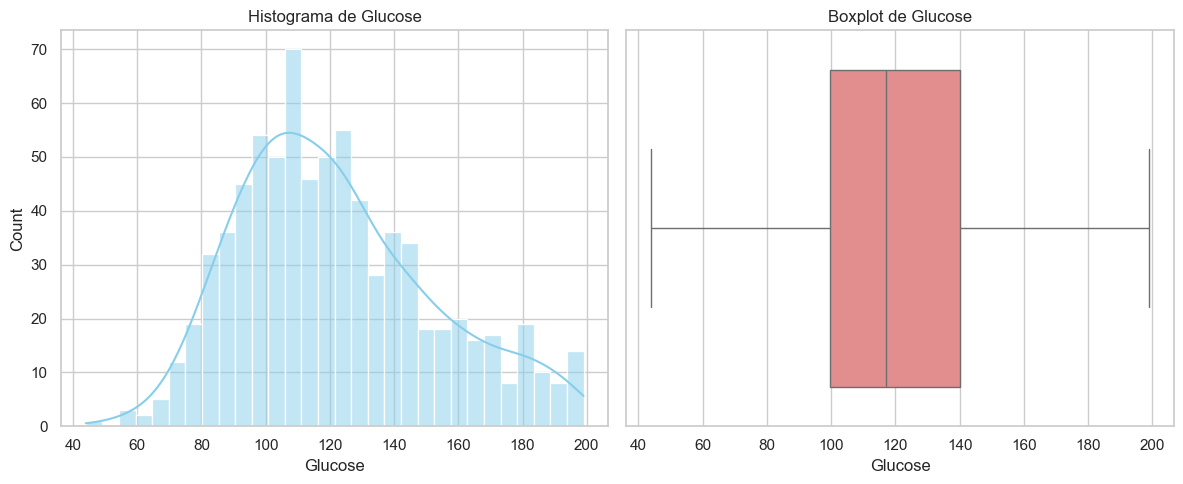

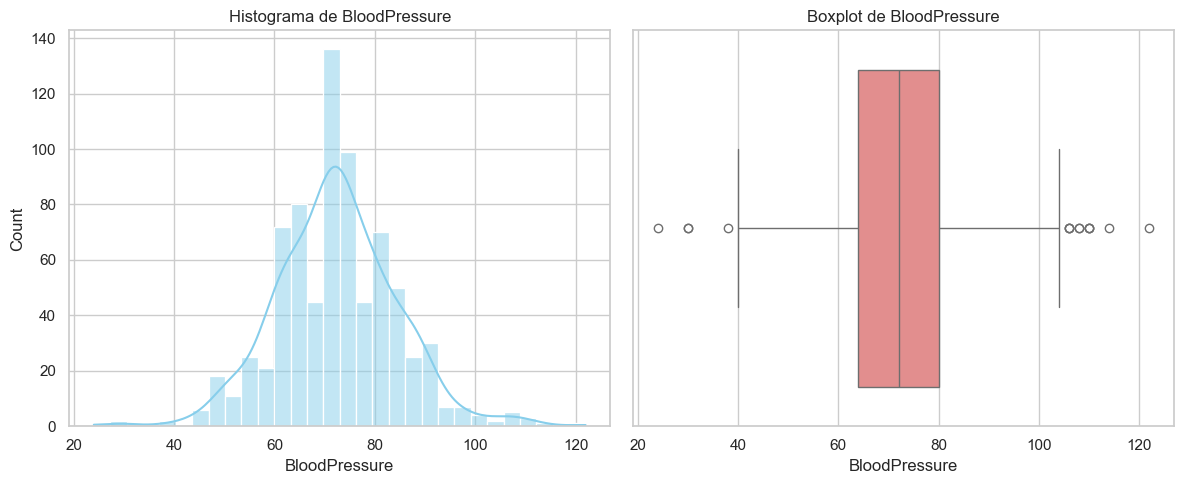

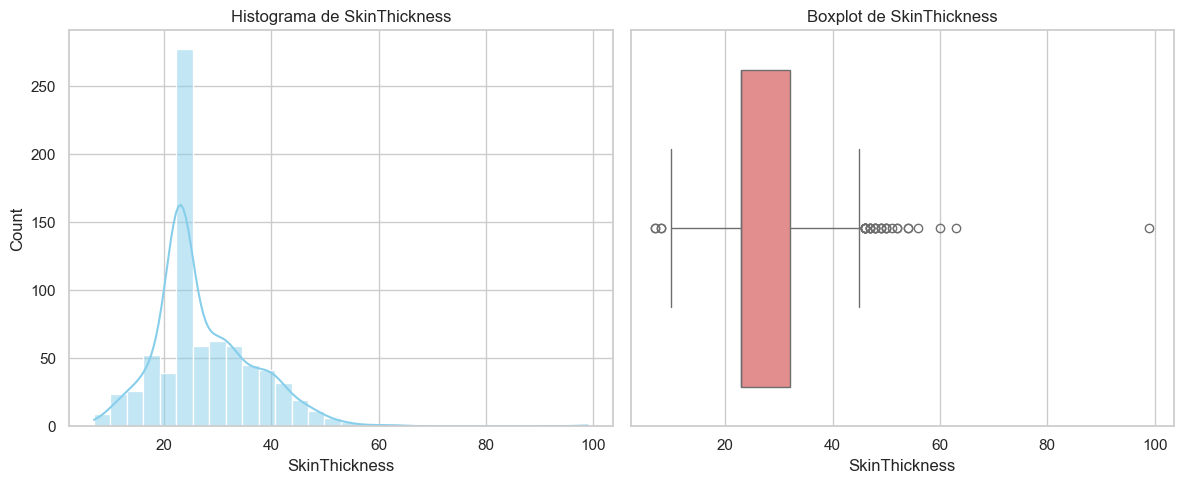

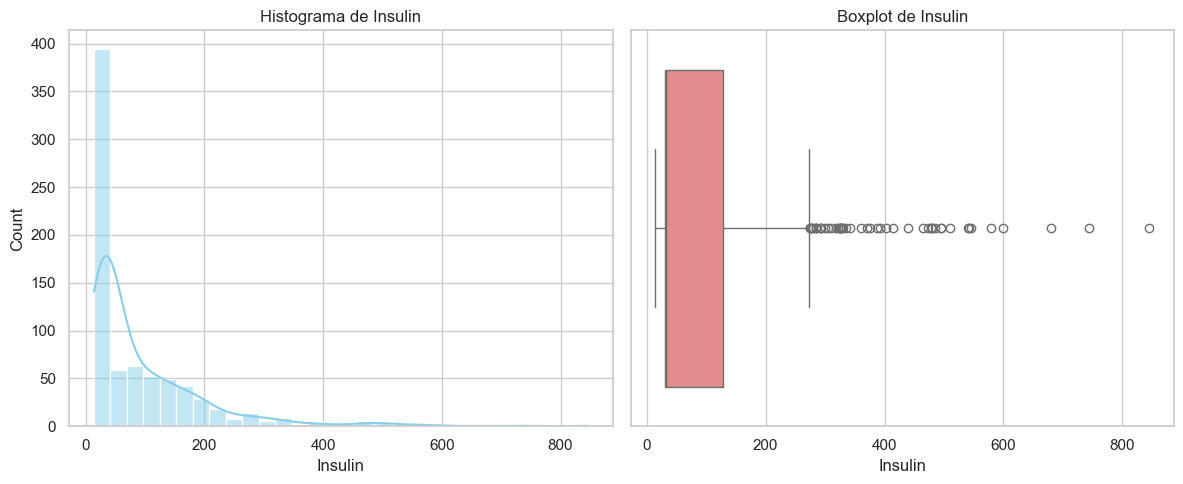

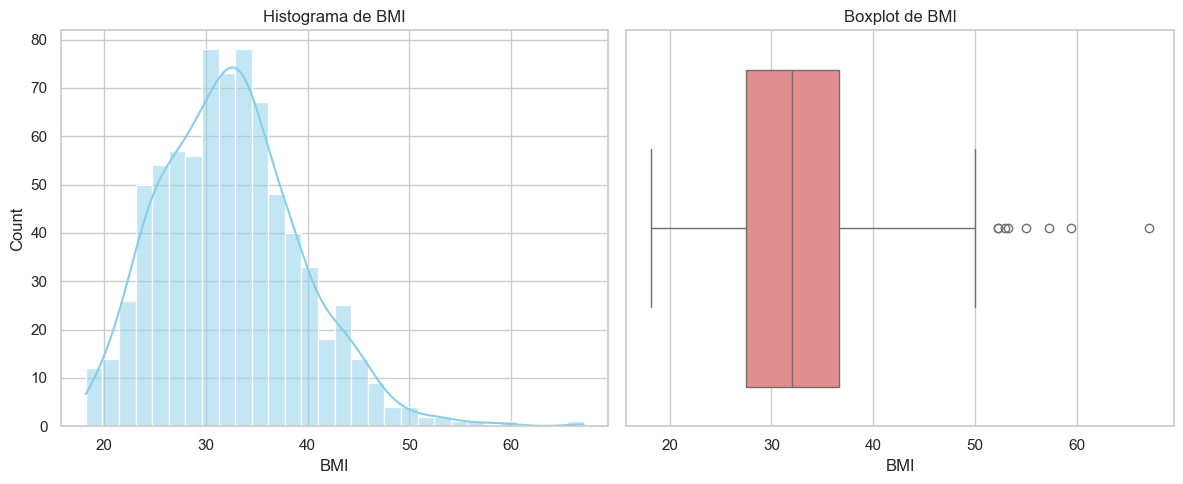

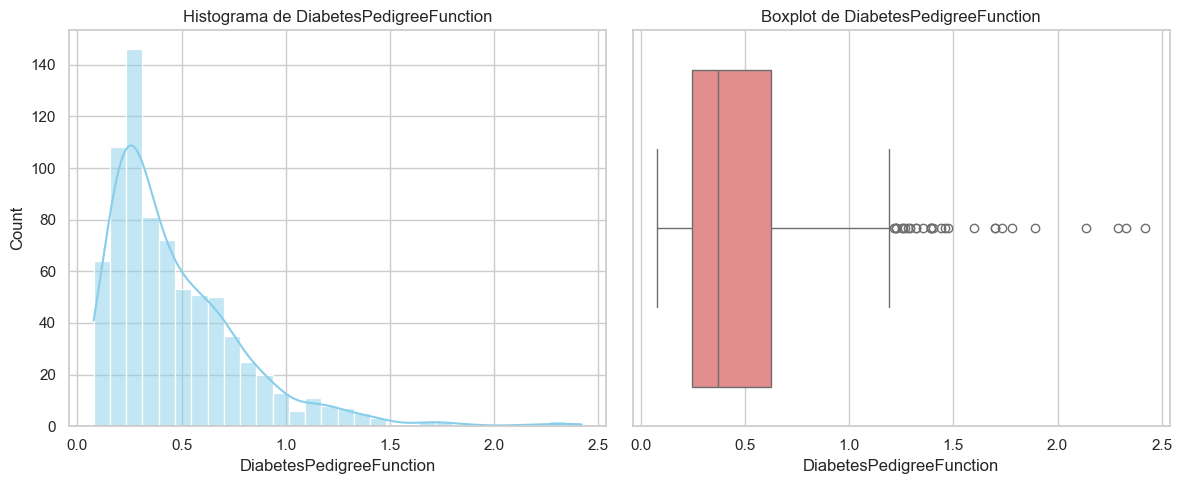

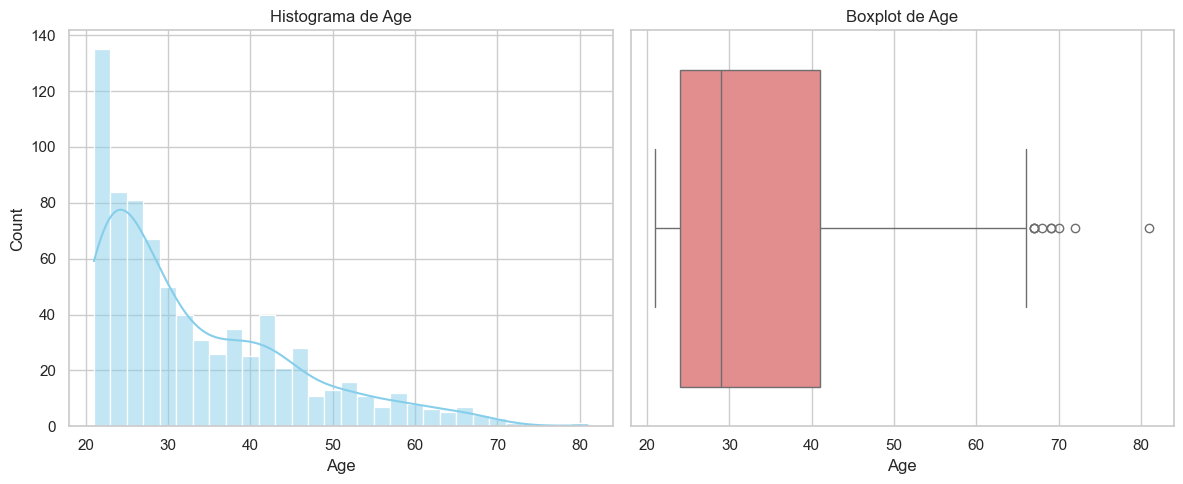

In [38]:
sns.set(style="whitegrid")
numeric_cols = df.columns[:-1] 


for col in numeric_cols:
    plt.figure(figsize=(12, 5))
    
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma de {col}')
    
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

#### Observaciones, 
la Glucosa y el BMI muestran una disttribucion normal ligeramente sesgada hacia la derecha, Insulin, SkinTThickness y DiabetesPedigreeFunction tienen muchos valores hacia la derecha. Age nos muestra que tenemos mas pacientes ente los 20 y los 40 años y Pregnancies tiene una distribucion sesgada a la izquierda es decir que muchos embarazos son de 0 a 2 y con pocos valores alttos

## Analisis bivariante con la objetivo

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


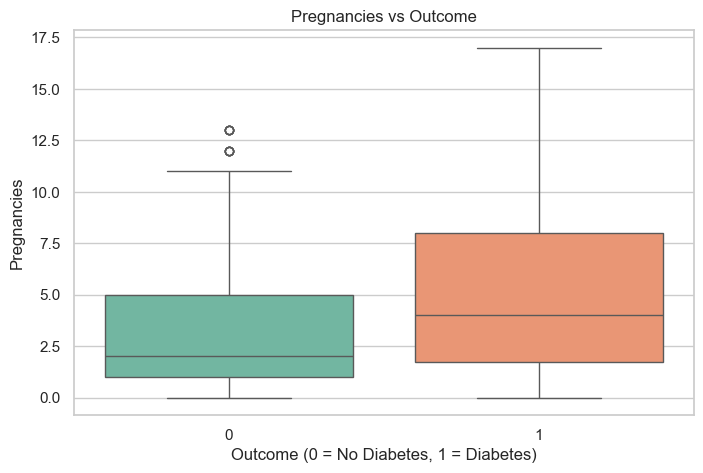

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


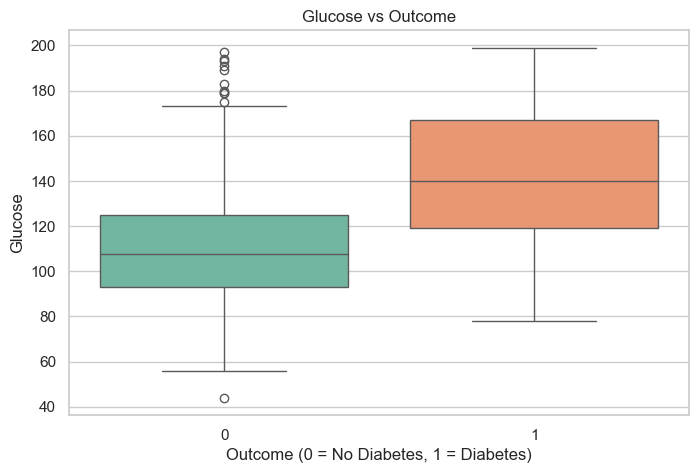

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


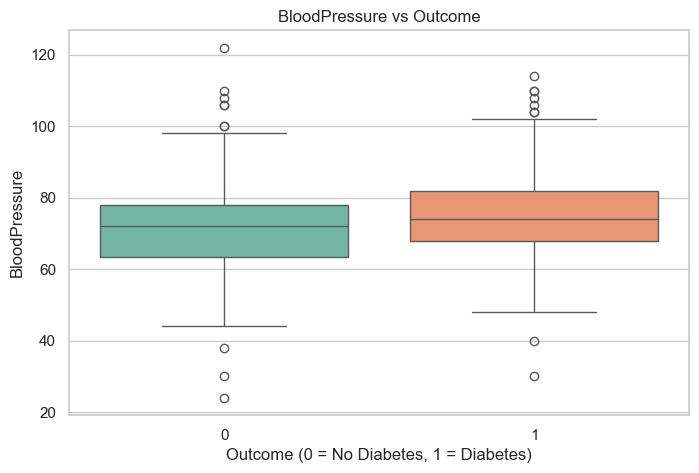

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


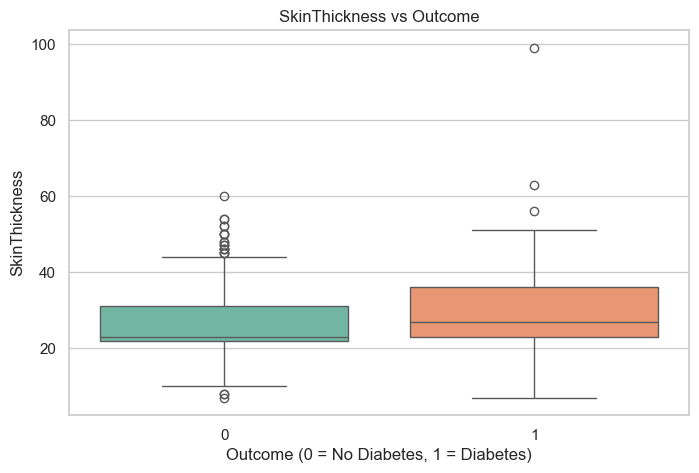

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


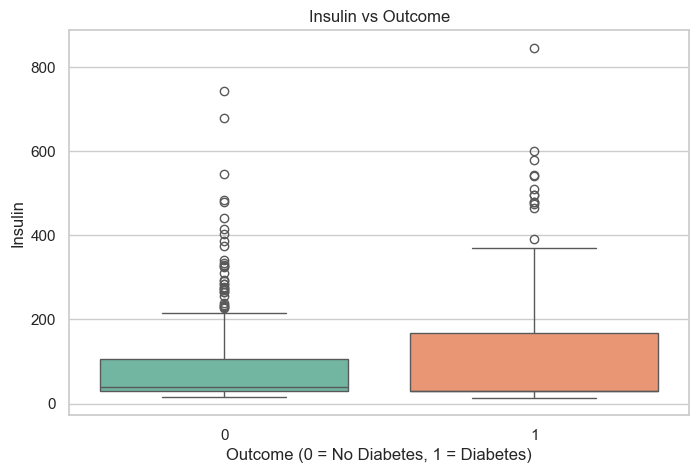

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


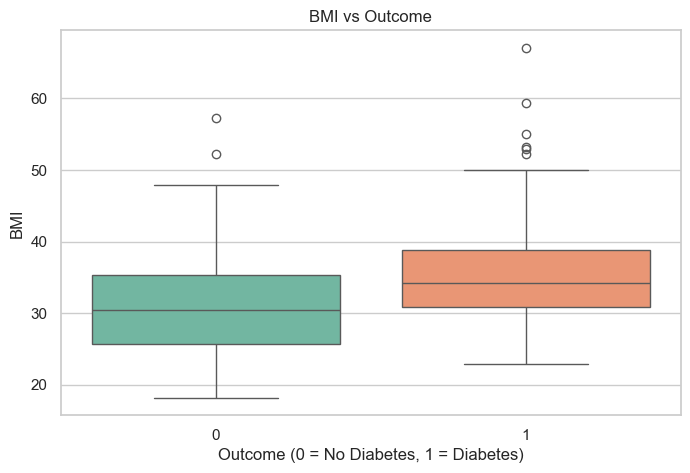

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


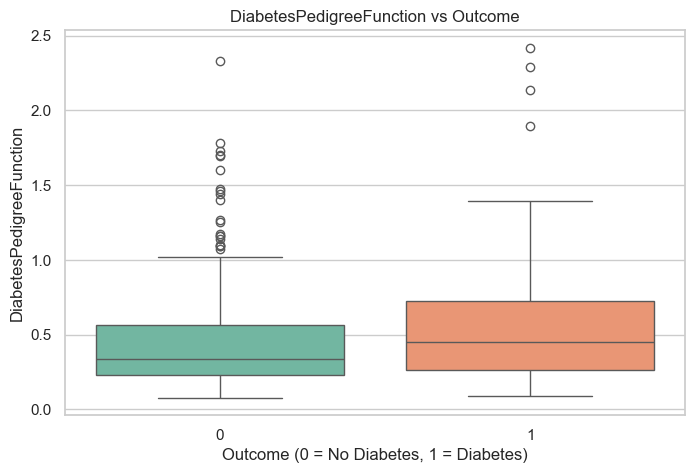

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\1952058244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")


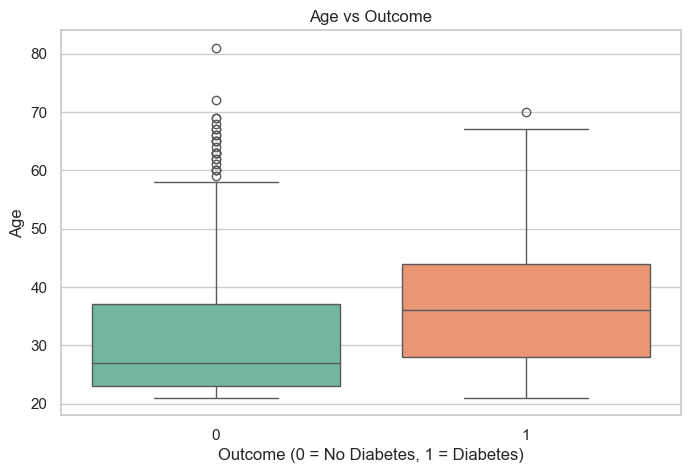

In [39]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Outcome', y=col, palette="Set2")
    plt.title(f'{col} vs Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(col)
    plt.show()

Glucosa:
Las personas con diabetes (Outcome = 1) tienden a tener niveles de glucosa mas altos, es una variable importante

BMI:
Las personas diabeticas tienden a tener un IMC mas alto que las no diabeticas.
    
Age:
Los casos de diabetes aumentan con la edad

Pregnancies:
Puede parecer que a mas embarazos mayor es la posibildad de tener diabetes, esto puede ser por la diabetes gestacional algo comun durante el embarazo pero que no nos sirve para predecir bien
 
BloodPressure:
La presion sanguinia tampoco nos dice mucho, no nos sirve para predecir ya que estan ambas variables muy repartidas

SkinThickness e Insulin:
Ambas tienen gran presencia de Outliers lo que nos complica mucho a la hora de analizarlas

DiabetesPedigreeFunction:
Tiende a ser mas alta en diabeticos, lo que nos podria decir presencia genetica

### Tratar Insulin y Skinthickness con KNNimputer

Paso 1 reemplazaremos los outliers con valores nulos

In [40]:
def iqr_outliers_to_nan(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: np.nan if x < lower or x > upper else x)
    return df

cols_to_process = ['SkinThickness', 'Insulin']
for col in cols_to_process:
    df = iqr_outliers_to_nan(df, col)

In [41]:
df['SkinThickness'] = np.log1p(df['SkinThickness'])
df['Insulin'] = np.log1p(df['Insulin'])

Paso 2 Aplicaremos KNNImputer

In [ ]:
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

Paso 3 Graficaremos otra vez las variables Insulin y Skintthickness

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\840383672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imputed, x='Outcome', y=col, palette='Set2')


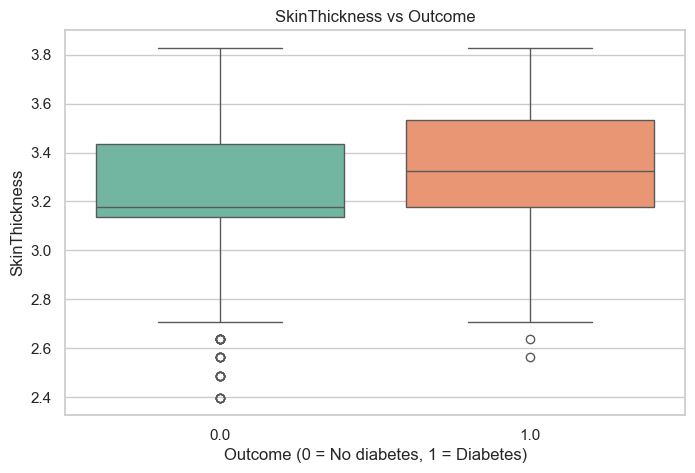

C:\Users\nahue\AppData\Local\Temp\ipykernel_17336\840383672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_imputed, x='Outcome', y=col, palette='Set2')


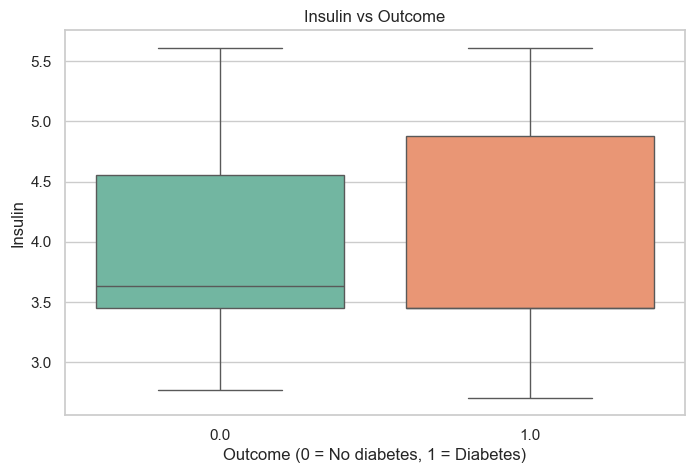

In [52]:
for col in ['SkinThickness', 'Insulin']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_imputed, x='Outcome', y=col, palette='Set2')
    plt.title(f'{col} vs Outcome')
    plt.xlabel('Outcome (0 = No diabetes, 1 = Diabetes)')
    plt.ylabel(col)
    plt.show()

### Conclusion 
Estas dos variables (Insuline y SkinThickness) siguen sin ser claras pese a transformarlas, Si es cierto que los casos de diabetes  ligeramente con la insulina mas alta o el Grosor mas alto pero no es tan claro como otras variables. En combinacion a otras variables como la Glucosa si que pueden resultar mas predictoras

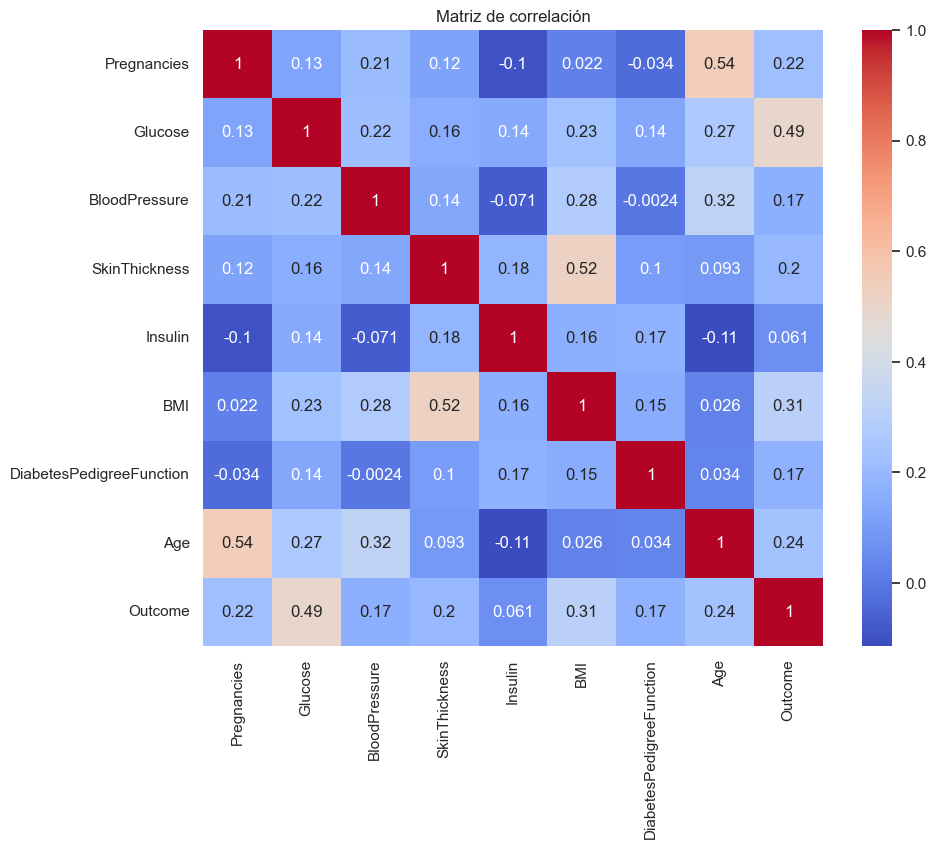

In [53]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [54]:
X = df_imputed.drop("Outcome", axis=1)
y = df_imputed["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)


In [56]:
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


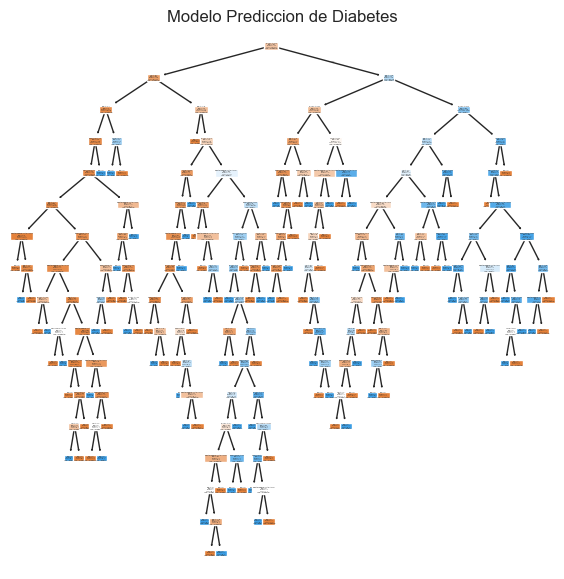

In [57]:
plt.figure(figsize=(7, 7))

plot_tree(model,
          feature_names=list(X_train.columns),
          class_names=["No Diabetes", "Diabetes"],
          filled=True)

plt.title("Modelo Prediccion de Diabetes")
plt.show()

=== MÉTRICAS DEL MODELO ===
Accuracy Train: 1.000
Accuracy Test: 0.714

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79       100
         1.0       0.61      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


=== MATRIZ DE CONFUSIÓN ===


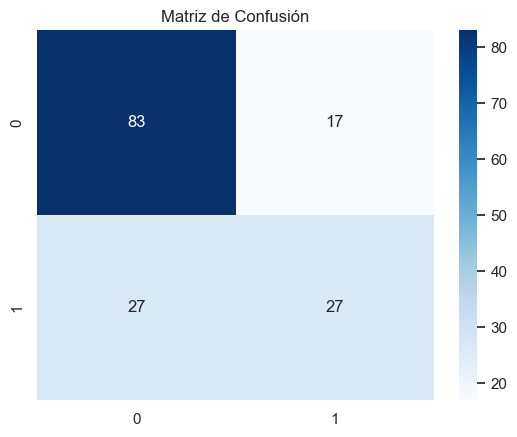

In [58]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluar rendimiento
print("=== MÉTRICAS DEL MODELO ===")
print(f"Accuracy Train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy Test: {accuracy_score(y_test, y_pred_test):.3f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_test))

print("\n=== MATRIZ DE CONFUSIÓN ===")
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

# Conclusion

Nuestro modelo DecisionTree despues del tratamiento de variables y las trasformaciones con KNNimputer, nos queda un 0,71 de precision. Algo bajo pero que en futuros proyectos mejoraremos con tecnicas de optimizacion o con el uso de otros modelos

In [59]:
with open('modelo_diabetes_tree.pkl', 'wb') as file:
    pickle.dump(model, file)